<a href="https://colab.research.google.com/github/nsiriwardhana/construction-safety-monitor/blob/dev/construction_safety_monitor_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="KxLJU9ZrYgATbdi5JLml")
project = rf.workspace("nipuni-siriwardhana-s-workspace").project("construction-safety-monitor")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [2]:
import os

print("Dataset folder:", dataset.location)
print("Files inside dataset folder:")
print(os.listdir(dataset.location))
print("\nPath to data.yaml:")
print(os.path.join(dataset.location, "data.yaml"))

Dataset folder: /content/construction-safety-monitor-1
Files inside dataset folder:
['train', 'data.yaml', 'README.roboflow.txt', 'test', 'README.dataset.txt', 'valid']

Path to data.yaml:
/content/construction-safety-monitor-1/data.yaml


In [3]:
with open("/content/construction-safety-monitor-1/data.yaml", "r") as f:
    print(f.read())

names:
- helmet
- person
- vest
nc: 3
roboflow:
  license: CC BY 4.0
  project: construction-safety-monitor
  url: https://universe.roboflow.com/nipuni-siriwardhana-s-workspace/construction-safety-monitor/dataset/1
  version: 1
  workspace: nipuni-siriwardhana-s-workspace
test: ../test/images
train: ../train/images
val: ../valid/images



In [4]:
import os
from glob import glob

base = dataset.location

train_images = glob(os.path.join(base, "train", "images", "*"))
valid_images = glob(os.path.join(base, "valid", "images", "*"))
test_images  = glob(os.path.join(base, "test", "images", "*"))

train_labels = glob(os.path.join(base, "train", "labels", "*"))
valid_labels = glob(os.path.join(base, "valid", "labels", "*"))
test_labels  = glob(os.path.join(base, "test", "labels", "*"))

print("TRAIN images:", len(train_images))
print("TRAIN labels:", len(train_labels))
print("VALID images:", len(valid_images))
print("VALID labels:", len(valid_labels))
print("TEST images :", len(test_images))
print("TEST labels :", len(test_labels))

TRAIN images: 1108
TRAIN labels: 1108
VALID images: 106
VALID labels: 106
TEST images : 52
TEST labels : 52


In [5]:
!pip install ultralytics

In [6]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

In [7]:
model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640
)

Ultralytics 8.4.31 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/construction-safety-monitor-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7a45605aff80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [8]:
import os

os.listdir("/content/runs/detect")

['train3', 'train', 'train4', 'predict', 'train2', 'val']

In [9]:
os.listdir("/content/runs/detect/train4/weights")

['best.pt', 'last.pt']

In [10]:
from ultralytics import YOLO

best_model = YOLO("/content/runs/detect/train4/weights/best.pt")

In [11]:
import os
from glob import glob

test_images = glob(f"{dataset.location}/test/images/*")
print("Number of test images:", len(test_images))
print("Sample image:", test_images[0])

Number of test images: 52
Sample image: /content/construction-safety-monitor-1/test/images/00552_jpg.rf.df44455b95caedebfb09e9aa2f90a4ee.jpg


In [12]:
results = best_model.predict(
    source=test_images[0],
    conf=0.25,
    save=True
)


image 1/1 /content/construction-safety-monitor-1/test/images/00552_jpg.rf.df44455b95caedebfb09e9aa2f90a4ee.jpg: 640x640 3 helmets, 3 persons, 8.4ms
Speed: 1.8ms preprocess, 8.4ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict2


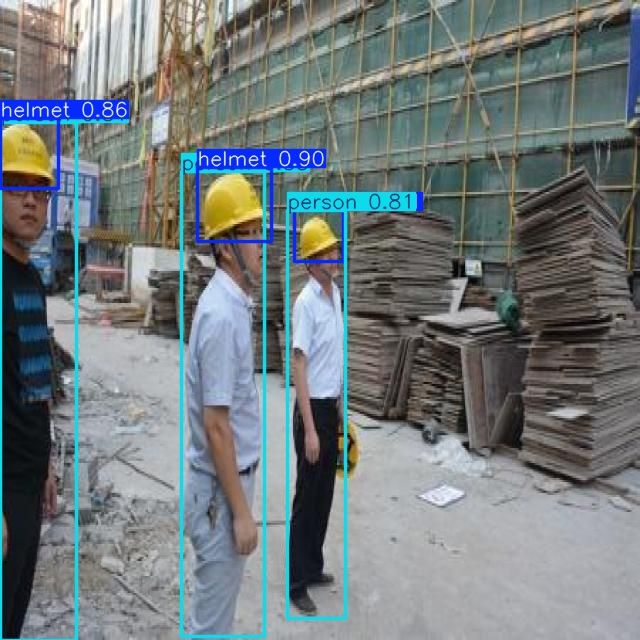

In [13]:
from IPython.display import Image, display
import os

pred_folder = "/content/runs/detect/predict"
files = os.listdir(pred_folder)

display(Image(filename=os.path.join(pred_folder, files[0])))

In [14]:
result = results[0]

for box in result.boxes:
    cls = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()

    label = best_model.names[cls]

    print(label, conf, xyxy)

helmet 0.8960446715354919 [197.25845336914062, 167.0877685546875, 271.7825927734375, 241.59375]
person 0.8810965418815613 [181.16058349609375, 171.83836364746094, 264.87481689453125, 636.0782470703125]
helmet 0.8609457612037659 [0.0, 118.70032501220703, 58.94792938232422, 188.17352294921875]
person 0.8146592974662781 [287.15472412109375, 210.600830078125, 345.62396240234375, 618.4920654296875]
helmet 0.8111433982849121 [294.3223876953125, 210.61468505859375, 343.91357421875, 261.46490478515625]
person 0.8100618124008179 [0.231689453125, 122.0908203125, 76.10134887695312, 640.0]


In [19]:
def classify_worker(person_box, helmet_boxes, vest_boxes):
    has_helmet = any(center_inside(h, person_box) for h in helmet_boxes)
    has_vest = any(center_inside(v, person_box) for v in vest_boxes)

    if has_helmet and has_vest:
        return "safe", []

    missing = []
    if not has_helmet:
        missing.append("helmet")
    if not has_vest:
        missing.append("vest")

    return "unsafe", missing

In [20]:
for i, person_box in enumerate(person_boxes, start=1):
    status, missing = classify_worker(person_box, helmet_boxes, vest_boxes)

    if status == "safe":
        print(f"Worker {i}: SAFE")
    else:
        print(f"Worker {i}: UNSAFE (missing {', '.join(missing)})")

Worker 1: UNSAFE (missing vest)
Worker 2: UNSAFE (missing vest)
Worker 3: UNSAFE (missing vest)


In [21]:
safe_count = 0
unsafe_count = 0

worker_reports = []

for i, person_box in enumerate(person_boxes, start=1):
    status, missing = classify_worker(person_box, helmet_boxes, vest_boxes)

    if status == "safe":
        safe_count += 1
    else:
        unsafe_count += 1

    worker_reports.append({
        "worker_id": i,
        "status": status,
        "missing": missing
    })

scene_status = "SAFE" if unsafe_count == 0 else "UNSAFE"

print("\nScene Summary")
print("--------------------")
print(f"Workers detected: {len(person_boxes)}")
print(f"Safe workers: {safe_count}")
print(f"Unsafe workers: {unsafe_count}")
print(f"Scene status: {scene_status}")


Scene Summary
--------------------
Workers detected: 3
Safe workers: 0
Unsafe workers: 3
Scene status: UNSAFE


In [22]:
def analyze_scene(image_path):

    # Run detection
    results = best_model.predict(source=image_path, conf=0.25)
    result = results[0]

    person_boxes = []
    helmet_boxes = []
    vest_boxes = []

    for box in result.boxes:
        cls = int(box.cls[0])
        xyxy = box.xyxy[0].tolist()
        label = best_model.names[cls]

        if label == "person":
            person_boxes.append(xyxy)
        elif label == "helmet":
            helmet_boxes.append(xyxy)
        elif label == "vest":
            vest_boxes.append(xyxy)

    safe_count = 0
    unsafe_count = 0

    for i, person_box in enumerate(person_boxes, start=1):
        status, missing = classify_worker(person_box, helmet_boxes, vest_boxes)

        if status == "safe":
            safe_count += 1
        else:
            unsafe_count += 1

        if status == "safe":
            print(f"Worker {i}: SAFE")
        else:
            print(f"Worker {i}: UNSAFE (missing {', '.join(missing)})")

    scene_status = "SAFE" if unsafe_count == 0 else "UNSAFE"

    print("\nScene Summary")
    print("--------------------")
    print(f"Workers detected: {len(person_boxes)}")
    print(f"Safe workers: {safe_count}")
    print(f"Unsafe workers: {unsafe_count}")
    print(f"Scene status: {scene_status}")

In [33]:
analyze_scene(test_images[15])


image 1/1 /content/construction-safety-monitor-1/test/images/ppe_0557_jpg.rf.ed8c72e763e67e3d03648db013b4364a.jpg: 640x640 4 helmets, 4 persons, 4 vests, 19.1ms
Speed: 2.2ms preprocess, 19.1ms inference, 3.8ms postprocess per image at shape (1, 3, 640, 640)
Worker 1: SAFE
Worker 2: SAFE
Worker 3: SAFE
Worker 4: SAFE

Scene Summary
--------------------
Workers detected: 4
Safe workers: 4
Unsafe workers: 0
Scene status: SAFE


In [34]:
analyze_scene(test_images[5])


image 1/1 /content/construction-safety-monitor-1/test/images/Screenshot-216-_png.rf.740bbb21d46f83a574bc9c59f36841a0.jpg: 640x640 2 helmets, 5 persons, 7.3ms
Speed: 1.9ms preprocess, 7.3ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 640)
Worker 1: UNSAFE (missing helmet, vest)
Worker 2: UNSAFE (missing helmet, vest)
Worker 3: UNSAFE (missing vest)
Worker 4: UNSAFE (missing helmet, vest)
Worker 5: UNSAFE (missing vest)

Scene Summary
--------------------
Workers detected: 5
Safe workers: 0
Unsafe workers: 5
Scene status: UNSAFE


In [35]:
from google.colab import files

files.download("/content/runs/detect/train4/weights/best.pt")
files.download("/content/runs/detect/train4/results.png")
files.download("/content/runs/detect/train4/confusion_matrix.png")
files.download("/content/runs/detect/train4/labels.jpg")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>